Clasificación Automática de Frutas
Contexto:

Eres parte de un equipo que desarrolla una app para supermercados inteligentes. Tu tarea es crear un clasificador automático de frutas basado en dos características: peso (en gramos) y tamaño (en cm). El modelo debe aprender a distinguir entre Manzanas, Plátanos y Naranjas usando datos generados de forma simulada.



Objetivo:

Construir una solución modular en Python que:

Genere datos aleatorios simulando las características físicas de frutas.

Entrene un clasificador K-Nearest Neighbors (KNN) con esos datos.

Permita predecir el tipo de fruta dados su peso y tamaño.

Muestre gráficamente los datos con colores distintos para cada fruta.

Rango de valores por tipo:

Manzana: peso entre 120–200g, tamaño entre 7–9cm

Plátano: peso entre 100–150g, tamaño entre 12–20cm

Naranja: peso entre 150–250g, tamaño entre 8–12cm

Datos generados (primeras filas):
         Peso    Tamaño    Fruta
0  149.963210  8.897771  Manzana
1  196.057145  8.931264  Manzana
2  178.559515  8.616795  Manzana
3  167.892679  7.609228  Manzana
4  132.481491  7.195344  Manzana 

Entrenamiento completado.

Precisión del modelo: 0.90

La fruta predicha para peso 140g y tamaño 18cm es: Plátano



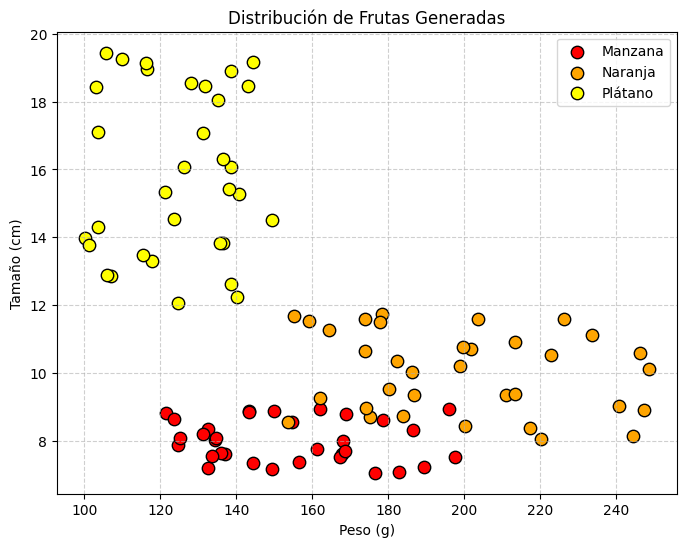

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# ------------------------------------------------------------
# Clase 1: GeneradorFrutas
# ------------------------------------------------------------
class GeneradorFrutas:
    def __init__(self, seed=42):
        np.random.seed(seed)

    def generar(self, num_muestras=100):
        # Cálculo del número de frutas de cada tipo
        n_manzanas = num_muestras // 3
        n_platanos = num_muestras // 3
        n_naranjas = num_muestras - n_manzanas - n_platanos

        # Manzanas
        peso_manzanas = np.random.uniform(120, 200, n_manzanas)
        tam_manzanas = np.random.uniform(7, 9, n_manzanas)
        etiquetas_manzanas = ["Manzana"] * n_manzanas

        # Plátanos
        peso_platanos = np.random.uniform(100, 150, n_platanos)
        tam_platanos = np.random.uniform(12, 20, n_platanos)
        etiquetas_platanos = ["Plátano"] * n_platanos

        # Naranjas
        peso_naranjas = np.random.uniform(150, 250, n_naranjas)
        tam_naranjas = np.random.uniform(8, 12, n_naranjas)
        etiquetas_naranjas = ["Naranja"] * n_naranjas

        # Unificación de datos
        peso = np.concatenate([peso_manzanas, peso_platanos, peso_naranjas])
        tamano = np.concatenate([tam_manzanas, tam_platanos, tam_naranjas])
        etiquetas = etiquetas_manzanas + etiquetas_platanos + etiquetas_naranjas

        data = pd.DataFrame({
            "Peso": peso,
            "Tamaño": tamano,
            "Fruta": etiquetas
        })

        return data


# ------------------------------------------------------------
# Clase 2: ClasificadorFrutas
# ------------------------------------------------------------
class ClasificadorFrutas:
    def __init__(self, k=5):
        self.k = k
        self.modelo = KNeighborsClassifier(n_neighbors=self.k)
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

    def entrenar(self, X, y):
        # División en entrenamiento y prueba
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Entrenamiento del modelo
        self.modelo.fit(self.X_train, self.y_train)
        print("Entrenamiento completado.\n")

    def evaluar(self):
        # Evaluación de precisión
        predicciones = self.modelo.predict(self.X_test)
        precision = accuracy_score(self.y_test, predicciones)
        print(f"Precisión del modelo: {precision:.2f}\n")
        return precision

    def predecir(self, peso, tamaño):
        muestra = np.array([[peso, tamaño]])
        prediccion = self.modelo.predict(muestra)[0]
        print(f"La fruta predicha para peso {peso}g y tamaño {tamaño}cm es: {prediccion}\n")
        return prediccion


# ------------------------------------------------------------
# Clase 3: VisualizadorFrutas
# ------------------------------------------------------------
class VisualizadorFrutas:
    def graficar(self, X, y, titulo="Frutas"):
        colores = {"Manzana": "red", "Plátano": "yellow", "Naranja": "orange"}
        plt.figure(figsize=(8, 6))

        for fruta in np.unique(y):
            idx = y == fruta
            plt.scatter(X[idx, 0], X[idx, 1],
                        label=fruta, color=colores[fruta], edgecolor="k", s=80)

        plt.title(titulo)
        plt.xlabel("Peso (g)")
        plt.ylabel("Tamaño (cm)")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()


# ------------------------------------------------------------
# Clase 4: SimuladorFrutas
# ------------------------------------------------------------
class SimuladorFrutas:
    def ejecutar(self):
        # 1. Generar datos
        generador = GeneradorFrutas()
        data = generador.generar(100)
        print("Datos generados (primeras filas):")
        print(data.head(), "\n")

        X = data[["Peso", "Tamaño"]].values
        y = data["Fruta"].values

        # 2. Entrenar el modelo
        clasificador = ClasificadorFrutas(k=5)
        clasificador.entrenar(X, y)

        # 3. Evaluar el modelo
        clasificador.evaluar()

        # 4. Predecir una nueva muestra
        clasificador.predecir(peso=140, tamaño=18)

        # 5. Visualizar los datos
        visualizador = VisualizadorFrutas()
        visualizador.graficar(X, y, titulo="Distribución de Frutas Generadas")


# ------------------------------------------------------------
# Ejecución del simulador
# ------------------------------------------------------------
if __name__ == "__main__":
    simulador = SimuladorFrutas()
    simulador.ejecutar()
